## Предобученные Fasttext -признаки

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import nltk
import nltk.corpus
import nltk.tokenize
import string
import gensim
from gensim.models import fasttext
from string import punctuation
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.utils.data as data_utils
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

Загрузка предобученной модели

geowac_tokens_none_fasttextskipgram_300_5_2020

In [40]:
from gensim.models import KeyedVectors

model_path = 'C:\\Users\\Landi\\Downloads\\214\\model.model'

model = KeyedVectors.load(model_path)

# Проверяем
print(f"Размер словаря: {len(model.key_to_index)}")
print(f"Пример слов: {list(model.key_to_index.keys())[4:13]}")

Размер словаря: 347295
Пример слов: ['размещено', '21', 'июля', 'в', '11', 'автор', 'admin', 'ключевые', 'теги']


In [14]:
model.most_similar('работа')

[('работка', 0.7625467777252197),
 ('работенка', 0.6732190251350403),
 ('.работа', 0.6701401472091675),
 ('совместная', 0.6353870630264282),
 ('кропотливая', 0.6325235962867737),
 ('надомная', 0.626720666885376),
 ('проделана', 0.6196900606155396),
 ('профессия', 0.6145178079605103),
 (',работа', 0.6143660545349121),
 ('работет', 0.607315182685852)]

In [13]:
model.key_to_index['работа']

298

In [15]:
model[model.key_to_index['работа']]

array([-0.17828257,  0.12579593, -0.12276635, -0.06854536, -0.25141096,
       -0.30400792, -0.04715535,  0.06150865,  0.5680058 ,  0.10428492,
        0.26862225, -0.46509552,  0.1539766 ,  0.00949502,  0.12211671,
        0.14950304,  0.00799078,  0.28955793, -0.26117352, -0.42254373,
       -0.09299713,  0.41995096,  0.07447747, -0.36210433, -0.16573672,
       -0.04424574,  0.30185965, -0.35211766,  0.7734306 ,  0.29764828,
        0.31040752, -0.27866706,  0.02715313, -0.49294135, -0.42772746,
       -0.00441068, -0.07894694, -0.40096843, -0.09435192,  0.01355699,
        0.33008283,  0.29533097,  0.09844936, -0.5031138 , -0.13228257,
       -0.03876182, -0.33891943, -0.940842  ,  0.24276143,  0.32169098,
        0.07956532, -0.06844971, -0.03561277, -0.34584013,  0.15323311,
       -0.00196571,  0.10581437,  0.21753567, -0.23789023, -0.18717466,
        0.01279921, -0.07786804,  0.25601748, -0.2570043 , -0.29069224,
        0.2629316 ,  0.30457544,  0.08531663, -0.42331564,  0.35

In [17]:
model.similarity('кошка', 'собака').item()

0.8840195536613464

In [18]:
model.similarity('кошка', 'день').item()

0.23762427270412445

In [19]:
negative_file='C:\\Users\\Landi\\ИТМО\\2 сем\\NLP\\lab1\\negative.csv'
positive_file='C:\\Users\\Landi\\ИТМО\\2 сем\\NLP\\lab1\\positive.csv'

#считываем файл
negative_df = pd.read_csv(negative_file, delimiter=";",header=None, names=["id", "tdate", "tmane",'ttext', 'ttype', 'trep', 'trtv','tfav', 'tstcount', 'tfol', 'tfrien', 'listcount'], nrows=10000)
positive_df = pd.read_csv(positive_file, delimiter=";",header=None, names=["id", "tdate", "tmane",'ttext', 'ttype', 'trep', 'trtv','tfav', 'tstcount', 'tfol', 'tfrien', 'listcount'], nrows=10000)

sentiment = pd.concat([negative_df, positive_df])[['ttext', 'ttype']]
sentiment.loc[(sentiment.ttype < 0), ('ttype')] = 0
sentiment

,ttext,ttype
0,на работе был полный пиддес :| и так каждое за...,0
1,"Коллеги сидят рубятся в Urban terror, а я из-з...",0
2,@elina_4post как говорят обещаного три года жд...,0
3,"Желаю хорошего полёта и удачной посадки,я буду...",0
4,"Обновил за каким-то лешим surf, теперь не рабо...",0
...,...,...
9995,"Все равно, я бы чувствовала себя лучше, если б...",1
9996,-Я пошла вешаться...-Что?! Что случилось?-Проб...,1
9997,"Идеальный перерыв с любимой Катюхой, пиано мас...",1
9998,Удахгүй дүн гарахаар мэдээлэл хийнээ :)) http:...,1


In [20]:
#разделяем датасет на train и test
X=sentiment['ttext'].values.tolist()
y=sentiment['ttype'].values.tolist()

In [21]:
#разбиваем на токены
punctuations = list(punctuation)
punkt = ['``','...',"''",'«','»','…','”','”','“','-','–','..']
punctuations.extend(punkt)

def tokenize(text):
    text_token = nltk.word_tokenize(text)
    text_word=[x.lower() for x in text_token if x not in punctuations]
    return text_word


In [22]:
X_token = [tokenize(t) for t in X]

In [23]:
sentiment

,ttext,ttype
0,на работе был полный пиддес :| и так каждое за...,0
1,"Коллеги сидят рубятся в Urban terror, а я из-з...",0
2,@elina_4post как говорят обещаного три года жд...,0
3,"Желаю хорошего полёта и удачной посадки,я буду...",0
4,"Обновил за каким-то лешим surf, теперь не рабо...",0
...,...,...
9995,"Все равно, я бы чувствовала себя лучше, если б...",1
9996,-Я пошла вешаться...-Что?! Что случилось?-Проб...,1
9997,"Идеальный перерыв с любимой Катюхой, пиано мас...",1
9998,Удахгүй дүн гарахаар мэдээлэл хийнээ :)) http:...,1


In [25]:
sentiment = pd.read_csv('sentiment_processed.csv')
sentiment.head()

,id,ttext,ttype
0,408906762813579264,"['работа', 'полный', 'пиддеса', 'каждый', 'зак...",0
1,408906818262687744,"['коллега', 'сидеть', 'рубиться', 'из-за', 'до...",0
2,408906858515398656,"['говорить', 'обещаной', 'год', 'ждать']",0
3,408906914437685248,"['желать', 'хороший', 'полет', 'удачный', 'пос...",0
4,408906914723295232,"['обновлять', 'какой-то', 'леший', 'работать',...",0


In [27]:
def word_averaging(model, words):
    all_words, mean = set(), []

    for word in words:
        if word in model.key_to_index.keys():
            mean.append(model[model.key_to_index[word]])
            all_words.add(model.key_to_index[word])

    if not mean:
        #logging.warning("cannot compute similarity with no input %s", words)
        # FIXME: remove these examples in pre-processing
        return np.zeros(model.vector_size)

    mean = gensim.matutils.unitvec(np.array(mean).mean(axis=0)).astype(np.float32)
    return mean

In [28]:
def  word_averaging_list(model, text_list):
    return np.vstack([word_averaging(model, comment_text) for comment_text in text_list ])

In [26]:
#разделяем датасет на train и test
X=sentiment['ttext'].values.tolist()
y=sentiment['ttype'].values.tolist()

In [29]:
X = word_averaging_list(model, X)
X.shape

(20000, 300)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [31]:
# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
def plot_confusion(model_name, y_pred, y_test):
   
    # Матрица ошибок
    cm = confusion_matrix(y_test, y_pred)
    
    # Подписи классов
    labels = ["Отрицательный", "Положительный"]
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=labels,
                yticklabels=labels)
    plt.xlabel("Предсказанные метки")
    plt.ylabel("Истинные метки")
    plt.title(f"Матрица ошибок ({model_name})")
    plt.show()

In [33]:
# Создание и обучение модели
svc = SVC(random_state=42, kernel='rbf')
svc.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False



Classification report:

               precision    recall  f1-score   support

           0       0.59      0.59      0.59      2990
           1       0.59      0.59      0.59      3010

    accuracy                           0.59      6000
   macro avg       0.59      0.59      0.59      6000
weighted avg       0.59      0.59      0.59      6000



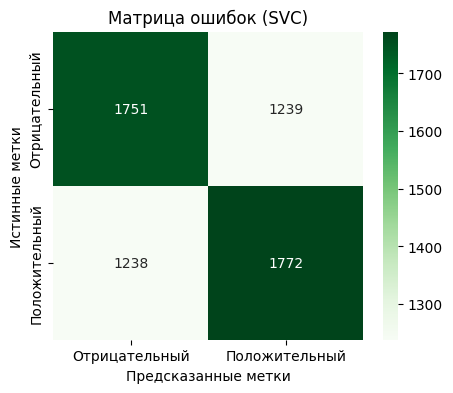

In [34]:
# Предсказания
y_pred_svc = svc.predict(X_test_scaled)

print("\nClassification report:\n\n", classification_report(y_test, y_pred_svc))
plot_confusion("SVC", y_pred_svc, y_test)